### Setup + sanity check (paths + image load)

Working dir image exists?: True
Absolute path: /mnt/c/datasets/streetscapes/snapshot.jpg
cv2.imread type: <class 'numpy.ndarray'>
img is None?: False
shape (H, W, C): (1080, 1920, 3)
dtype: uint8
min/max: 0 255


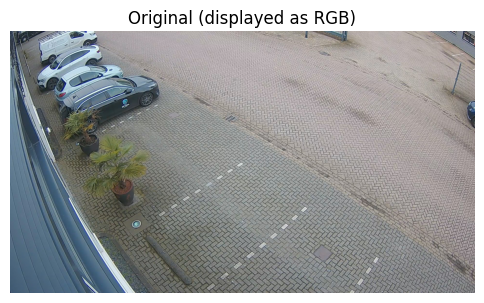

In [13]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH = Path("/mnt/c/datasets/streetscapes/snapshot.jpg")

print("Working dir image exists?:", IMAGE_PATH.exists())
print("Absolute path:", IMAGE_PATH.resolve())

img = cv2.imread(str(IMAGE_PATH))
print("cv2.imread type:", type(img))
print("img is None?:", img is None)

print("shape (H, W, C):", img.shape)
print("dtype:", img.dtype)
print("min/max:", img.min(), img.max())

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original (displayed as RGB)")
plt.axis("off")
plt.show()

### ROI slicing (what img[y1:y2, x1:x2] really does)

Image shape: (1080, 1920, 3)
ROI coords (x1,y1,x2,y2): (480, 270, 1440, 810)
ROI shape: (540, 960, 3)


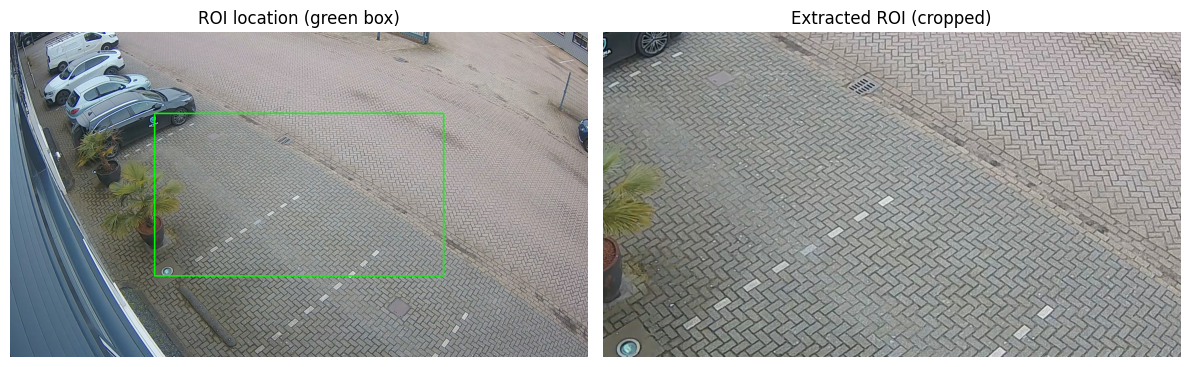

In [14]:
H, W = img.shape[:2]
x1, y1 = int(W * 0.25), int(H * 0.25)
x2, y2 = int(W * 0.75), int(H * 0.75)

roi = img[y1:y2, x1:x2]

print("Image shape:", img.shape)
print("ROI coords (x1,y1,x2,y2):", (x1, y1, x2, y2))
print("ROI shape:", roi.shape)

# Draw rectangle on a copy for visualization
vis = img.copy()
cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 3)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title("ROI location (green box)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
plt.title("Extracted ROI (cropped)")
plt.axis("off")

plt.tight_layout()
plt.show()

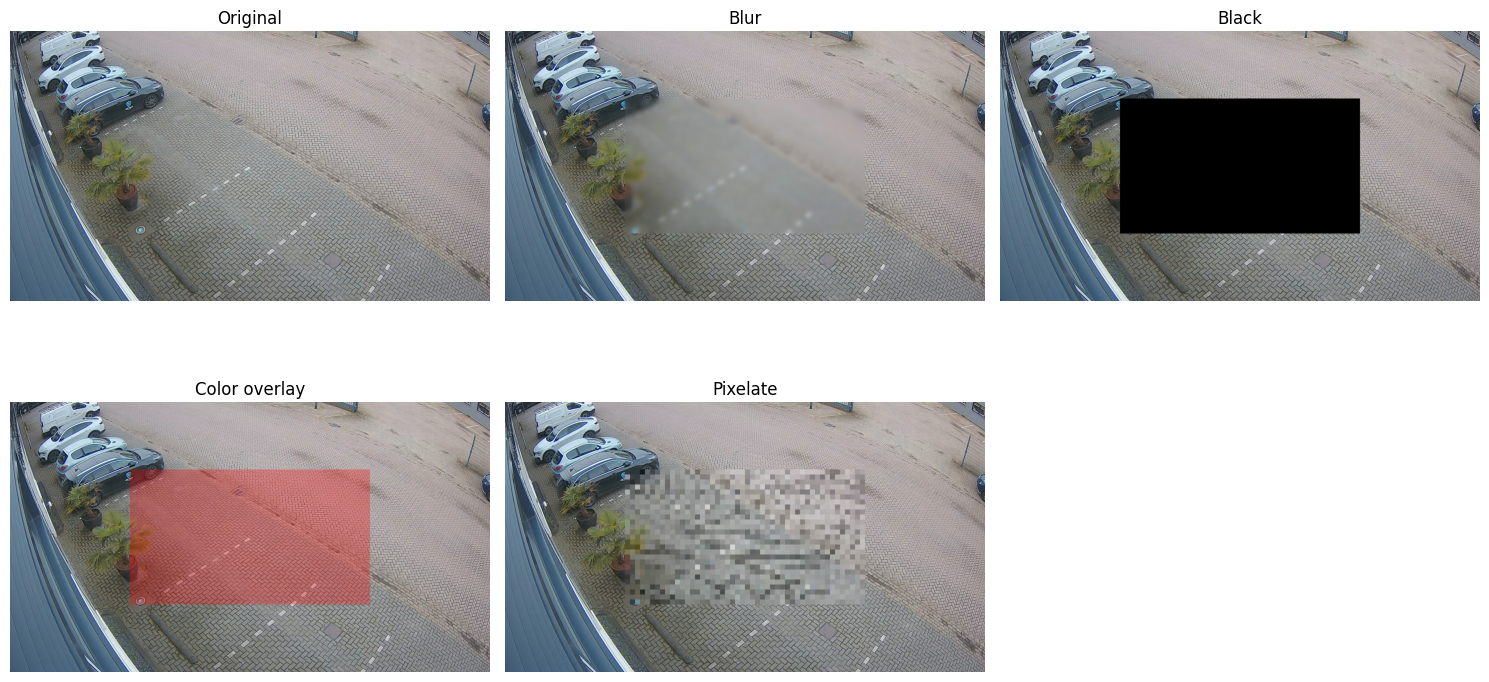

In [15]:
def blur_region(img_in, x1, y1, x2, y2):
    out = img_in.copy()
    roi = out[y1:y2, x1:x2]
    out[y1:y2, x1:x2] = cv2.GaussianBlur(roi, (51, 51), 0)
    return out

def black_region(img_in, x1, y1, x2, y2):
    out = img_in.copy()
    out[y1:y2, x1:x2] = 0
    return out

def color_region(img_in, x1, y1, x2, y2, bgr=(0, 0, 255), alpha=0.3):
    out = img_in.copy()
    roi = out[y1:y2, x1:x2]
    overlay = np.full_like(roi, bgr, dtype=np.uint8)
    out[y1:y2, x1:x2] = cv2.addWeighted(roi, 1 - alpha, overlay, alpha, 0)
    return out

def pixelate_region(img_in, x1, y1, x2, y2, pixel=20):
    out = img_in.copy()
    roi = out[y1:y2, x1:x2]
    h, w = roi.shape[:2]
    small = cv2.resize(roi, (max(1, w // pixel), max(1, h // pixel)), interpolation=cv2.INTER_LINEAR)
    out[y1:y2, x1:x2] = cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)
    return out

variants = [
    ("Original", img),
    ("Blur", blur_region(img, x1, y1, x2, y2)),
    ("Black", black_region(img, x1, y1, x2, y2)),
    ("Color overlay", color_region(img, x1, y1, x2, y2)),
    ("Pixelate", pixelate_region(img, x1, y1, x2, y2)),
]

plt.figure(figsize=(15, 8))
for i, (title, im) in enumerate(variants):
    plt.subplot(2, 3, i + 1)
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

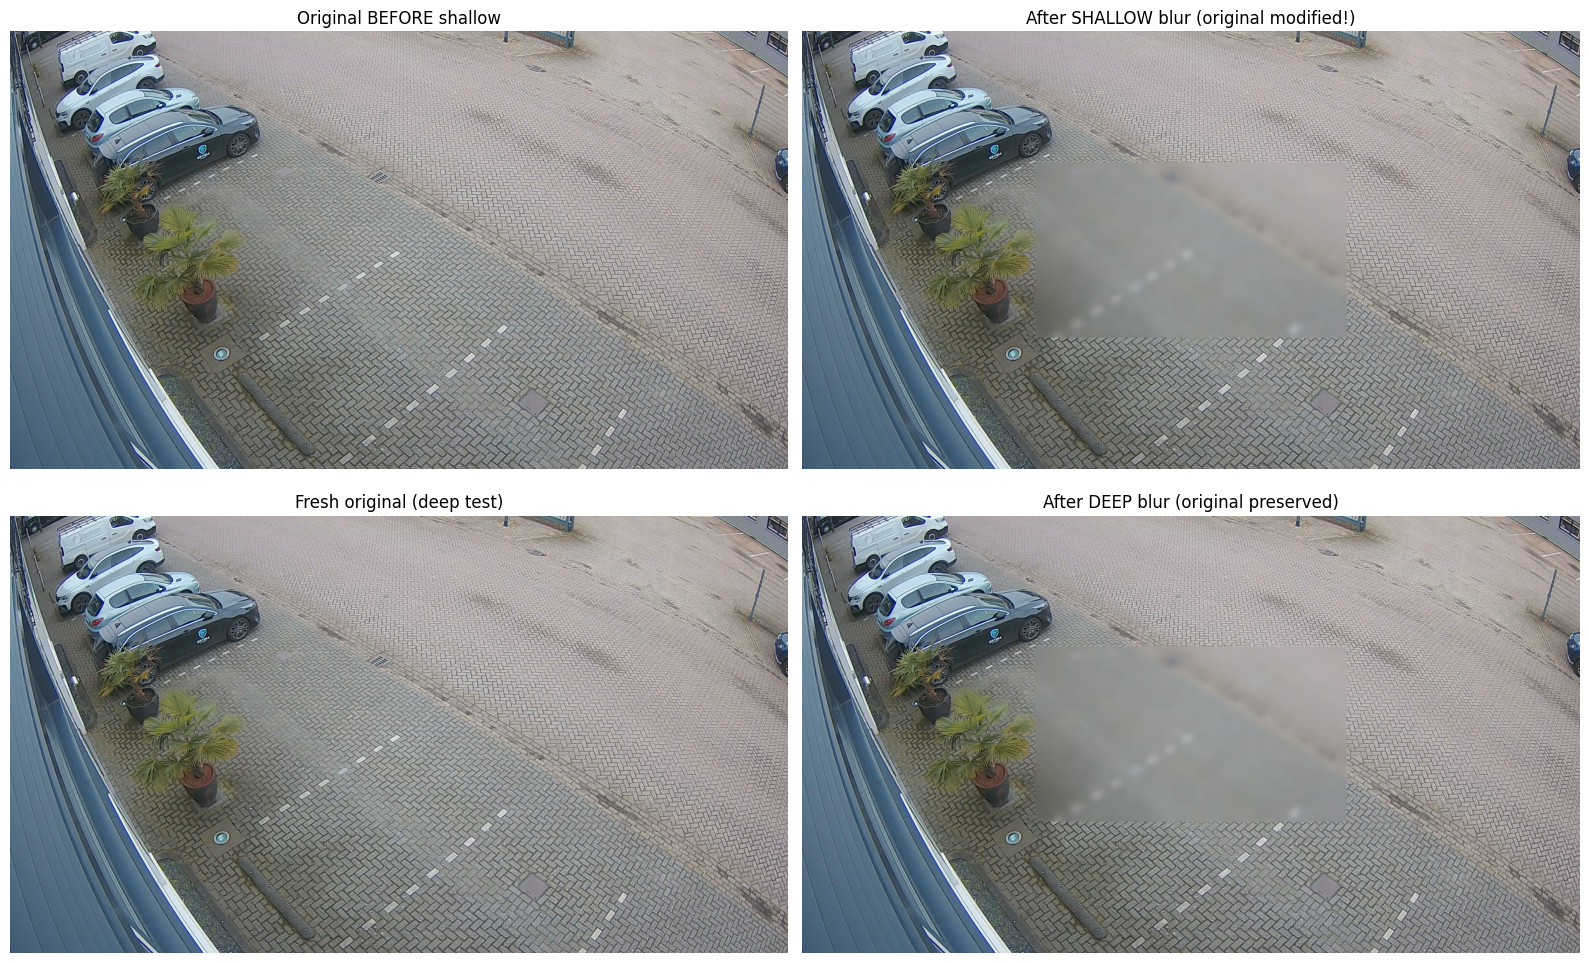

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load fresh image
img_original = cv2.imread("/mnt/c/datasets/streetscapes/snapshot.jpg")

# Define ROI area
H, W = img_original.shape[:2]
x1, y1 = int(W * 0.3), int(H * 0.3)
x2, y2 = int(W * 0.7), int(H * 0.7)

# -----------------------------
# 1️⃣ SHALLOW COPY (reference)
# -----------------------------
img_shallow = img_original  # NO copy
roi_shallow = img_shallow[y1:y2, x1:x2]
blurred_shallow = cv2.GaussianBlur(roi_shallow, (51, 51), 0)

img_shallow[y1:y2, x1:x2] = blurred_shallow

# -----------------------------
# Reload image for deep copy test
# -----------------------------
img_original2 = cv2.imread("/mnt/c/datasets/streetscapes/snapshot.jpg")

# -----------------------------
# 2️⃣ DEEP COPY
# -----------------------------
img_deep = img_original2.copy()  # REAL copy
roi_deep = img_deep[y1:y2, x1:x2]
blurred_deep = cv2.GaussianBlur(roi_deep, (51, 51), 0)

img_deep[y1:y2, x1:x2] = blurred_deep

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(16, 10))

images = [
    ("Original BEFORE shallow", cv2.imread("/mnt/c/datasets/streetscapes/snapshot.jpg")),
    ("After SHALLOW blur (original modified!)", img_original),
    ("Fresh original (deep test)", img_original2),
    ("After DEEP blur (original preserved)", img_deep),
]

for i, (title, im) in enumerate(images):
    plt.subplot(2, 2, i + 1)
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Apply your masking to YOLO boxes and show original vs masked


image 1/1 /mnt/c/datasets/streetscapes/snapshot.jpg: 384x640 6 cars, 2 potted plants, 320.8ms
Speed: 1.3ms preprocess, 320.8ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)
Result object: <class 'ultralytics.engine.results.Results'>
Names available?: True
Number of detections: 8

--- Detections ---
01:          car conf=0.89 box=(110,56,383,249) size=(273x193)
02: potted plant conf=0.84 box=(297,422,585,722) size=(288x300)
03:          car conf=0.82 box=(186,177,619,394) size=(433x217)
04:          car conf=0.82 box=(113,0,363,137) size=(250x137)
05:          car conf=0.81 box=(180,136,470,296) size=(290x160)
06: potted plant conf=0.62 box=(213,317,376,514) size=(163x197)
07:          car conf=0.59 box=(1885,282,1919,404) size=(34x122)
08:          car conf=0.59 box=(26,0,145,52) size=(119x52)


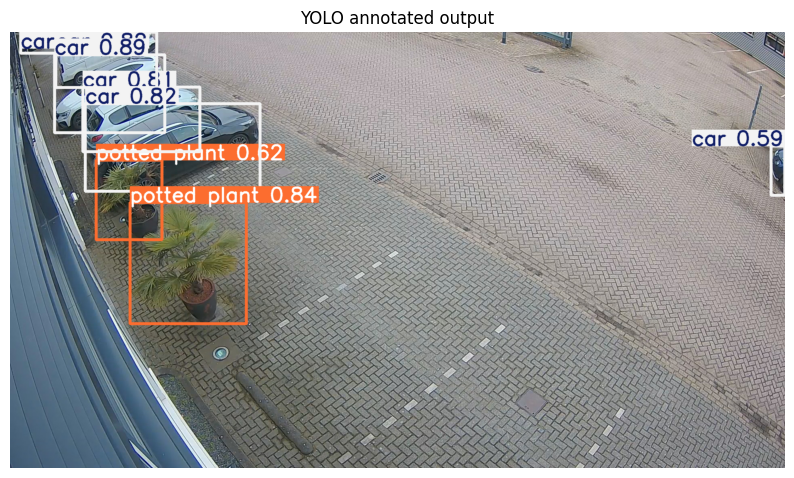

In [17]:
from ultralytics import YOLO

model = YOLO("/mnt/c/datasets/yolov8/models/yolov8l.pt")  # or yolov8m.pt etc.

results = model(str(IMAGE_PATH), conf=0.3)
r = results[0]

print("Result object:", type(r))
print("Names available?:", hasattr(model, "names"))
print("Number of detections:", len(r.boxes))

boxes_xyxy = r.boxes.xyxy.cpu().numpy() if r.boxes is not None else np.empty((0, 4))
cls = r.boxes.cls.cpu().numpy() if getattr(r.boxes, "cls", None) is not None else np.array([])
conf = r.boxes.conf.cpu().numpy() if getattr(r.boxes, "conf", None) is not None else np.array([])

print("\n--- Detections ---")
for i in range(len(boxes_xyxy)):
    x1_, y1_, x2_, y2_ = map(int, boxes_xyxy[i])
    cls_id = int(cls[i]) if len(cls) else -1
    name = model.names.get(cls_id, str(cls_id)) if hasattr(model, "names") else str(cls_id)
    c = float(conf[i]) if len(conf) else float("nan")
    print(f"{i+1:02d}: {name:>12} conf={c:.2f} box=({x1_},{y1_},{x2_},{y2_}) size=({x2_-x1_}x{y2_-y1_})")

annotated = r.plot()  # BGR image with boxes/labels drawn

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title("YOLO annotated output")
plt.axis("off")
plt.show()

### Visualize each detection ROI (cropped objects)

This is very helpful to “see” what YOLO thinks it detected.

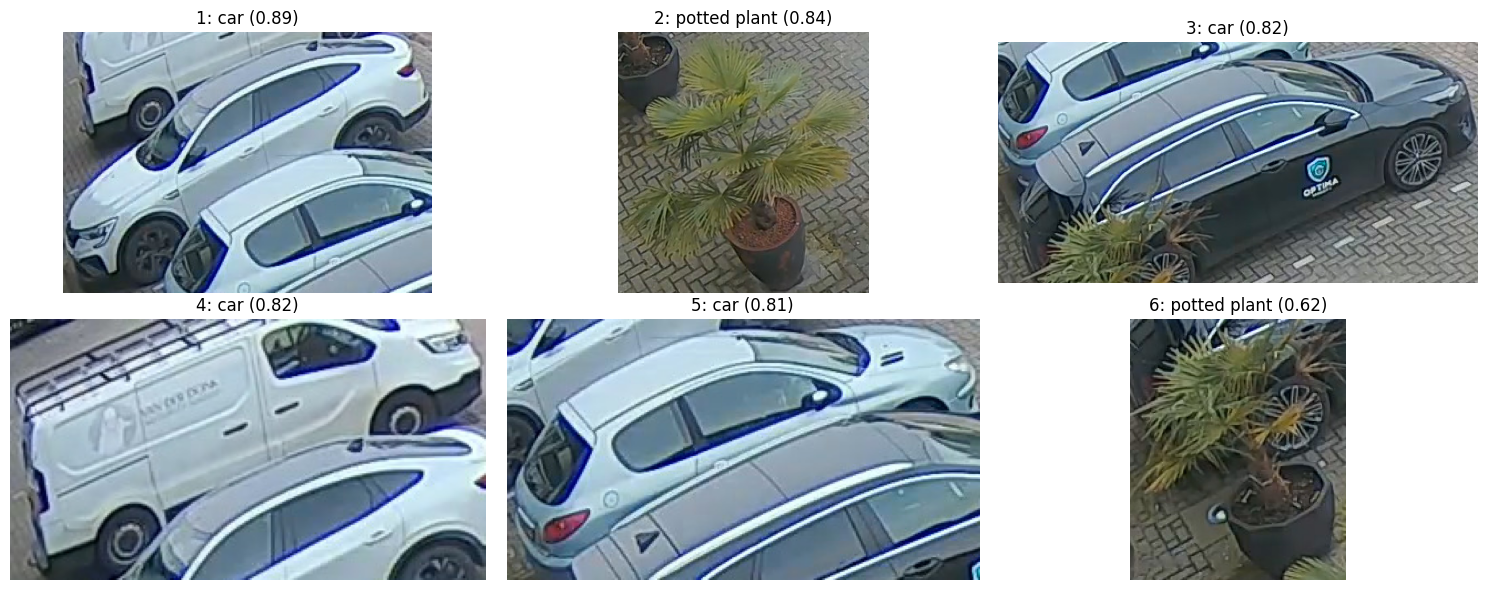

In [18]:
img_bgr = cv2.imread(str(IMAGE_PATH))

rois = []
roi_titles = []

for i in range(len(boxes_xyxy)):
    x1_, y1_, x2_, y2_ = map(int, boxes_xyxy[i])
    crop = img_bgr[y1_:y2_, x1_:x2_]
    if crop.size == 0:
        continue
    cls_id = int(cls[i])
    name = model.names.get(cls_id, str(cls_id))
    rois.append(crop)
    roi_titles.append(f"{i+1}: {name} ({conf[i]:.2f})")

n = min(len(rois), 6)  # show first 6
plt.figure(figsize=(15, 6))
for i in range(n):
    plt.subplot(2, 3, i + 1)
    plt.imshow(cv2.cvtColor(rois[i], cv2.COLOR_BGR2RGB))
    plt.title(roi_titles[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

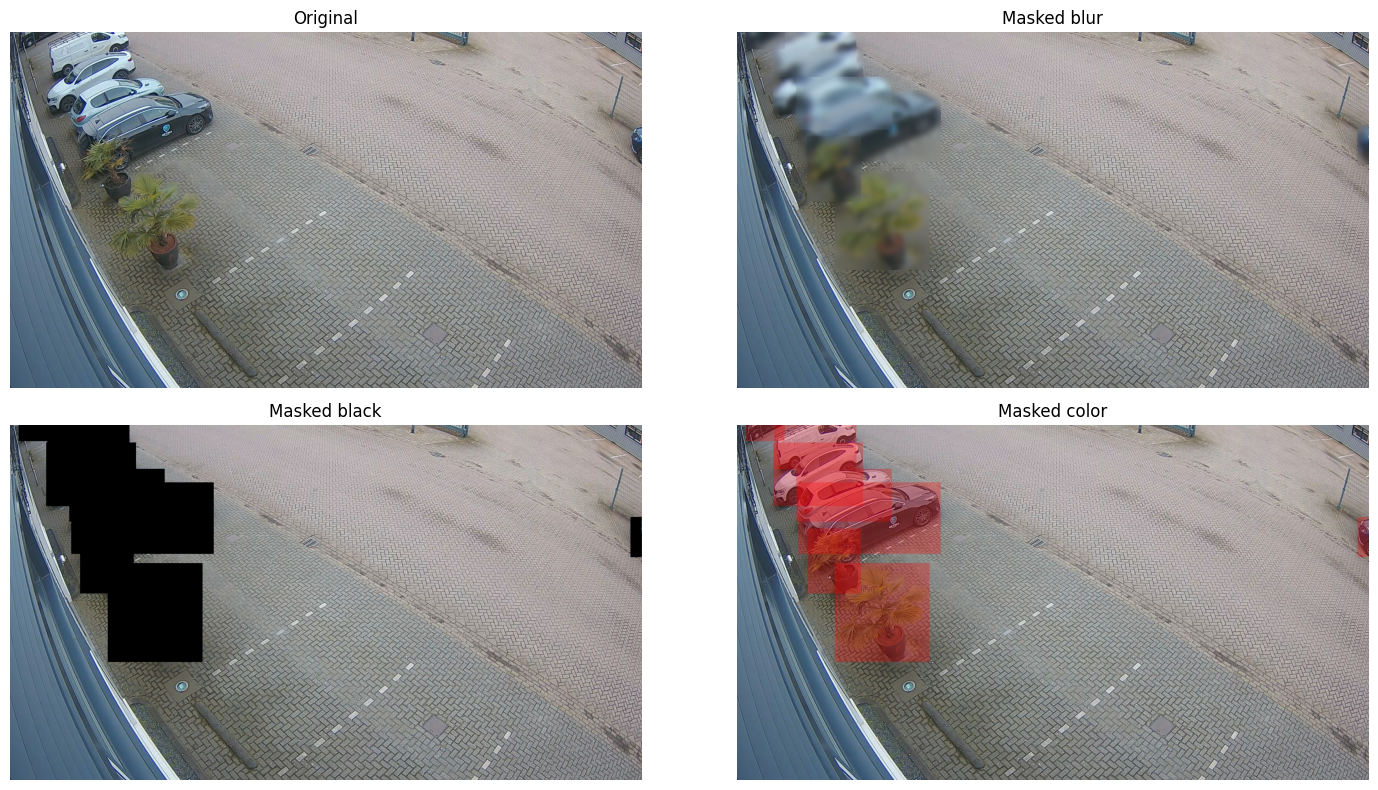

In [19]:
def mask_boxes(img_in, boxes_xyxy, mode="blur"):
    out = img_in.copy()
    for (x1_, y1_, x2_, y2_) in boxes_xyxy.astype(int):
        roi = out[y1_:y2_, x1_:x2_]
        if roi.size == 0:
            continue

        match mode:
            case "blur":
                out[y1_:y2_, x1_:x2_] = cv2.GaussianBlur(roi, (51, 51), 0)
            case "black":
                out[y1_:y2_, x1_:x2_] = 0
            case "color":
                overlay = np.full_like(roi, (0, 0, 255), dtype=np.uint8)
                out[y1_:y2_, x1_:x2_] = cv2.addWeighted(roi, 0.7, overlay, 0.3, 0)
            case _:
                raise ValueError(f"Unknown mode: {mode}")
    return out

original = cv2.imread(str(IMAGE_PATH))
masked_blur = mask_boxes(original, boxes_xyxy, mode="blur")
masked_black = mask_boxes(original, boxes_xyxy, mode="black")
masked_color = mask_boxes(original, boxes_xyxy, mode="color")

plt.figure(figsize=(15, 8))

for i, (title, im) in enumerate([
    ("Original", original),
    ("Masked blur", masked_blur),
    ("Masked black", masked_black),
    ("Masked color", masked_color),
]):
    plt.subplot(2, 2, i + 1)
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()